# Team I6 - Startup Fraud Training Simulator

Full pipeline: data -> encoder/decoder training -> scenario generation -> evaluation + feedback loop

## Setup

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import gdown
!pip install rouge_score -q

from pathlib import Path
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sklearn.metrics import f1_score, roc_auc_score
from scipy.linalg import sqrtm

  Preparing metadata (setup.py) ... done


## VAE Encoder

In [2]:
class VAEEncoder(nn.Module): # define neural network module
    def __init__(self, scenario_dim, profile_dim, hidden_dim=64, latent_dim=8):
        super().__init__() # constructor - defines dimensions, subject to change

        input_dim = scenario_dim + profile_dim # input = [s;c]

        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        ) # body of our encoder, just defines 2 linear functions and 2 ReLu for nn to pass through
        # this is also subject to change

        # for our latent space
        self.mu_layer = nn.Linear(hidden_dim, latent_dim) # mean
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim) # log variance


    def encode(self, s, c): # basically get mean and log variance from the combined distribution
        # Combine scenario skeleton and profile embedding
        h = torch.cat([s, c], dim=1)

        # Shared hidden representation
        h = self.shared(h)

        # Output latent Gaussian parameters
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)


        return mu, logvar

    def reparameterize(self, mu, logvar): # literally just z = mu + sigma * epsilon from our slides
        std = torch.exp(0.5 * logvar) # converts log variance to standard deviation
        eps = torch.randn_like(std) # defines epsilon as random noise with same shape as the standard deviation
        z = mu + std * eps # self explanatory
        return z # our latent vector

    def kl_divergence(self, mu, logvar): # this is just the KL-Divergence equation
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
        return kl.mean() # takes average from batch

    def forward(self, s, c): # this function is the data flow/path of our encoder

        mu, logvar = self.encode(s, c)
        z = self.reparameterize(mu, logvar)
        kl_loss = self.kl_divergence(mu, logvar)

        return z, mu, logvar, kl_loss

## VAE Decoder

In [3]:
# decoder: takes z (latent vector), c (profile embedding), d (difficulty) and reconstructs scenario tokens
# input is [z ; c ; d] concatenated, mirrors encoder architecture
class VAEDecoder(nn.Module):
    def __init__(self, latent_dim=8, profile_dim=16, hidden_dim=64, scenario_dim=22):
        super().__init__()

        # +1 for difficulty scalar
        input_dim = latent_dim + profile_dim + 1

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, scenario_dim)
        )

    def forward(self, z, c, d):
        # make d a proper tensor if its just a float
        if isinstance(d, (int, float)):
            d_tensor = torch.full((z.size(0), 1), float(d))
        else:
            d_tensor = d.view(-1, 1).float()

        x = torch.cat([z, c, d_tensor], dim=1)
        return self.network(x)  # s_hat

In [4]:
# reconstruction loss, L_VAE = L_rec + beta * KL
def reconstruction_loss(s, s_hat):
    return nn.functional.mse_loss(s_hat, s, reduction='mean')

## Load data

In [5]:
gdown.download(
    id="1FxT1RARt7XFxxkfeqdfHTuV-n5k64HZg",
    output="fraud_scenarios_encoded.csv",
    quiet=False
)

gdown.download(
    id="1TDviDEFoR4pkec6CTZuNNXbEnMOtian_",
    output="founder_profiles_encoded.csv",
    quiet=False
)

Scenario_DF = pd.read_csv("fraud_scenarios_encoded.csv")
Founder_DF = pd.read_csv("founder_profiles_encoded.csv")

# Converts the numerical scenario features into a PyTorch tensor.
Scenario_Tensor = torch.tensor(Scenario_DF.drop(
    columns=["scenario_id", "short_summary", "red_flags", "correct_action", "source", "fraud_type", "risk_level"]
).values, dtype=torch.float32)

# assuming fraud_type_encoded, risk_level_encoded, user_rating is the order

Founder_Tensor = torch.tensor(
    Founder_DF[
        ["stage", "sector", "funding", "team_size"]
    ].values, dtype=torch.float32
)

print(Scenario_Tensor.shape)
print(Founder_Tensor.shape)

Downloading...
From: https://drive.google.com/uc?id=1FxT1RARt7XFxxkfeqdfHTuV-n5k64HZg
To: /content/fraud_scenarios_encoded.csv
100%|██████████| 13.9k/13.9k [00:00<00:00, 10.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TDviDEFoR4pkec6CTZuNNXbEnMOtian_
To: /content/founder_profiles_encoded.csv
100%|██████████| 2.34k/2.34k [00:00<00:00, 6.40MB/s]

torch.Size([60, 3])
torch.Size([50, 4])


## Difficulty history (feedback loop simulation, used as training signal)

In [6]:
# random number generator fix state, 42 is an arbitrary value (can be any integer)
torch.manual_seed(42)

# choose between smaller of datasets (rows)
length = min(
    len(Scenario_Tensor),
    len(Founder_Tensor)
)

Scenario_Batch = Scenario_Tensor[:length]
Founder_Batch = Founder_Tensor[:length]

# we are assuming a 1:1 correspondance of profile to scenario

Ratings = Scenario_DF[
    "user_rating"
].iloc[:length].reset_index(
    drop=True
)

# stores difficulty value
Diff_History = []

# initial difficulty.
diff = 0.5

for i in range(length):
    rating = Ratings.iloc[i]

    if rating <= 2:
        diff -= 0.0875

    elif rating >= 4:
        diff += 0.0875

    diff = max(
        0.1,
        min(0.95, diff)
    )
    Diff_History.append(diff)

Difficulty_Batch = torch.tensor(
    Diff_History,
    dtype=torch.float32
).view(-1, 1)

print("Scenario shape:", Scenario_Batch.shape)
print("Founder shape:", Founder_Batch.shape)
print("Difficulty shape:", Difficulty_Batch.shape)

Scenario shape: torch.Size([50, 3])
Founder shape: torch.Size([50, 4])
Difficulty shape: torch.Size([50, 1])


## Train / validation split + normalization

In [7]:
# determines feature numbers
SCENARIO_DIM = Scenario_Batch.shape[1]
PROFILE_DIM = Founder_Batch.shape[1]

HIDDEN_DIM = 64
LATENT_DIM = 8

NUM_SAMPLES = length

# the number of training examples
TRAIN_SIZE = int(0.8 * NUM_SAMPLES)

# Generates a random ordering of every row index.
indices = torch.randperm(NUM_SAMPLES)

# 80/20 training/validation split

train_indices = indices[:TRAIN_SIZE]
val_indices = indices[TRAIN_SIZE:]

# extract training tensors for scenario, founder, and difficulty
S_Train_Raw = Scenario_Batch[train_indices]
C_Train_Raw = Founder_Batch[train_indices]
D_Train_Raw = Difficulty_Batch[train_indices]

# validation tensors
S_Val_Raw = Scenario_Batch[val_indices]
C_Val_Raw = Founder_Batch[val_indices]
D_Val_Raw = Difficulty_Batch[val_indices]


# normalization function
def normalize_train_and_val(train_tensor, val_tensor):
    # the minimum value of every feature in the training set
    minimum = train_tensor.min(
        dim=0
    ).values

    # the maximum value of every feature in the training set
    maximum = train_tensor.max(
        dim=0
    ).values

    # Calculates the range of every feature.
    feature_range = maximum - minimum

    # account for divison by zero (replace with 1)
    feature_range = torch.where(
        feature_range == 0,
        torch.ones_like(feature_range),
        feature_range
    )

    # Normalizes validation and training values into approximately the [0, 1] interval
    train_normalized = (
        train_tensor - minimum
    ) / feature_range

    val_normalized = (
        val_tensor - minimum
    ) / feature_range

    return (
        train_normalized,
        val_normalized,
        minimum,
        maximum
    )


# use normalized tensors
S_Train, S_Val, S_Min, S_Max = normalize_train_and_val(
    S_Train_Raw,
    S_Val_Raw
)

C_Train, C_Val, C_Min, C_Max = normalize_train_and_val(
    C_Train_Raw,
    C_Val_Raw
)

D_Train, D_Val, D_Min, D_Max = normalize_train_and_val(
    D_Train_Raw,
    D_Val_Raw
)

# difficulty is already bounded from 0.1 to 0.95, but normalizing it again should be okay

## Training loop

In [8]:
# Constructs a new encoder
encoder = VAEEncoder(
    scenario_dim=SCENARIO_DIM,
    profile_dim=PROFILE_DIM,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM
)
# construct new decoder
decoder = VAEDecoder(
    latent_dim=LATENT_DIM,
    profile_dim=PROFILE_DIM,
    hidden_dim=HIDDEN_DIM,
    scenario_dim=SCENARIO_DIM
)

LEARNING_RATE = 0.001
BETA = 0.01
EPOCHS = 100

# update weights based on gradient
optimizer = torch.optim.Adam(
    list(encoder.parameters())
    + list(decoder.parameters()),
    lr=LEARNING_RATE
)

# two empty lists for one each loss value per epoch.
train_loss_history = []
val_loss_history = []


# training loop

for epoch in range(EPOCHS):
    # training mode
    encoder.train()
    decoder.train()

    # clears previous gradient
    optimizer.zero_grad()

    # run encoder and decoder
    z, mu, logvar, kl_loss = encoder(
        S_Train,
        C_Train
    )

    S_Hat_Train = decoder(
        z,
        C_Train,
        D_Train
    )

    # mean-squared error between original and reconstructed scenarios.
    rec_loss = reconstruction_loss(
        S_Train,
        S_Hat_Train
    )

    total_loss = rec_loss + BETA * kl_loss

    # backprop
    total_loss.backward()
    # update weights
    optimizer.step()

    # records training loss
    train_loss_history.append(
        total_loss.item()
    )
    # evaluation mode
    encoder.eval()
    decoder.eval()

    # disables gradient because validation must not update the model
    with torch.no_grad():
        z_val, mu_val, logvar_val, kl_val = encoder(
            S_Val,
            C_Val
        )

        S_Hat_Val = decoder(
            mu_val,
            C_Val,
            D_Val
        )

        # validation reconstruction error
        rec_val = reconstruction_loss(
            S_Val,
            S_Hat_Val
        )

        val_loss = rec_val + BETA * kl_val

        val_loss_history.append(
            val_loss.item()
        )

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train Loss: {total_loss.item():.6f} | "
        f"Val Loss: {val_loss.item():.6f} | "
        f"Recon: {rec_loss.item():.6f} | "
        f"KL: {kl_loss.item():.6f}"
    )

Epoch 001 | Train Loss: 0.337653 | Val Loss: 0.401861 | Recon: 0.336740 | KL: 0.091302
Epoch 002 | Train Loss: 0.324793 | Val Loss: 0.388524 | Recon: 0.323928 | KL: 0.086542
Epoch 003 | Train Loss: 0.318545 | Val Loss: 0.375587 | Recon: 0.317712 | KL: 0.083332
Epoch 004 | Train Loss: 0.288302 | Val Loss: 0.362750 | Recon: 0.287496 | KL: 0.080570
Epoch 005 | Train Loss: 0.275062 | Val Loss: 0.350346 | Recon: 0.274268 | KL: 0.079400
Epoch 006 | Train Loss: 0.261660 | Val Loss: 0.338230 | Recon: 0.260864 | KL: 0.079571
Epoch 007 | Train Loss: 0.242298 | Val Loss: 0.326187 | Recon: 0.241489 | KL: 0.080909
Epoch 008 | Train Loss: 0.229785 | Val Loss: 0.314369 | Recon: 0.228947 | KL: 0.083816
Epoch 009 | Train Loss: 0.232537 | Val Loss: 0.302792 | Recon: 0.231665 | KL: 0.087219
Epoch 010 | Train Loss: 0.221621 | Val Loss: 0.291572 | Recon: 0.220702 | KL: 0.091868
Epoch 011 | Train Loss: 0.196378 | Val Loss: 0.281049 | Recon: 0.195404 | KL: 0.097402
Epoch 012 | Train Loss: 0.189721 | Val Loss

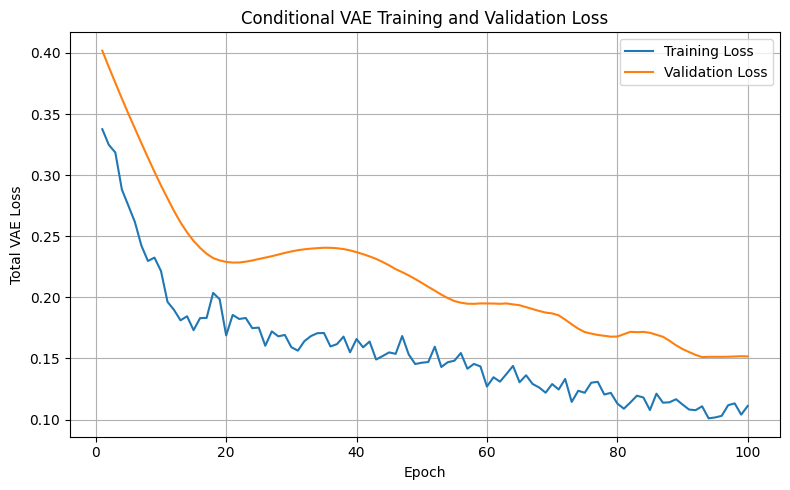

In [9]:
# fine for now, as long as final epoch is the best model - may have to change to keep lowest value
checkpoint = {
    "encoder_state_dict": encoder.state_dict(),
    "decoder_state_dict": decoder.state_dict(),
    "scenario_dim": SCENARIO_DIM,
    "profile_dim": PROFILE_DIM,
    "hidden_dim": HIDDEN_DIM,
    "latent_dim": LATENT_DIM,
    "scenario_min": S_Min,
    "scenario_max": S_Max,
    "profile_min": C_Min,
    "profile_max": C_Max,
    "difficulty_min": D_Min,
    "difficulty_max": D_Max,
    "train_loss_history": train_loss_history,
    "val_loss_history": val_loss_history,
    "learning_rate": LEARNING_RATE,
    "beta": BETA,
    "epochs": EPOCHS,

    "scenario_features": [
        "fraud_type_encoded",
        "risk_level_encoded",
        "user_rating"
    ],

    "profile_features": [
        "stage",
        "sector",
        "funding",
        "team_size"
    ],

    "train_indices": train_indices,
    "val_indices": val_indices,
}

torch.save(checkpoint, "trained_vae.pt")

epochs_axis = range(1, EPOCHS + 1)
plt.figure(figsize=(8, 5))

# draws the training-loss curve
plt.plot(
    epochs_axis,
    train_loss_history,
    label="Training Loss"
)

# draws the validation-loss curve
plt.plot(
    epochs_axis,
    val_loss_history,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Total VAE Loss")
plt.title("Conditional VAE Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("vae_loss_plot.png") # save as png
plt.show()

## Scenario generation (trained model)

In [10]:
# the same min/max normalization operation used in training
def normalize(values, minimum, maximum):
    feature_range = maximum - minimum
    feature_range = torch.where(
        feature_range == 0,
        torch.ones_like(feature_range),
        feature_range
    )

    return (values - minimum) / feature_range


# inverse of normalization to get the orignal scale values for scenario generation
def denormalize(values, minimum, maximum):
    return values * (maximum - minimum) + minimum


# we use continous parameters, so this is for that by checking minimum distance from valid codes/values
def nearest_valid_code(value, valid_codes):
    return min(
        valid_codes,
        key=lambda code: abs(code - value)
    )


def generate_scenario(decoder, founder_profile, difficulty, checkpoint, scenario_df, z=None):
    # converts founder profile to tensor
    profile_tensor = torch.tensor(
        [[
            founder_profile["stage"],
            founder_profile["sector"],
            founder_profile["funding"],
            founder_profile["team_size"]
        ]],
        dtype=torch.float32
    )

    # convert the raw founder profile to the normalized scale used during training
    profile_normalized = normalize(
        profile_tensor,
        checkpoint["profile_min"],
        checkpoint["profile_max"]
    )

    # same but with difficulty
    difficulty_tensor = torch.tensor(
        [[difficulty]],
        dtype=torch.float32
    )

    difficulty_normalized = normalize(
        difficulty_tensor,
        checkpoint["difficulty_min"],
        checkpoint["difficulty_max"]
    )

    # creates random latent vector if needed -> defined as none in declaration
    if z is None:
        # samples one latent vector from a standard normal distribution
        z = torch.randn(
            1,
            checkpoint["latent_dim"]
        )

    # disable gradient tracking because generation does not train the model
    with torch.no_grad():
        scenario_normalized = decoder(
            z,
            profile_normalized,
            difficulty_normalized
        )

    # clamp decoder incase its outside [0, 1] interval
    scenario_normalized = torch.clamp(
        scenario_normalized,
        min=0.0,
        max=1.0
    )
    # convert back to original scale
    scenario_raw = denormalize(
        scenario_normalized,
        checkpoint["scenario_min"],
        checkpoint["scenario_max"]
    )
    # extacts continous values
    generated_fraud_value = scenario_raw[0, 0].item()
    generated_risk_value = scenario_raw[0, 1].item()
    predicted_rating = scenario_raw[0, 2].item()

    valid_fraud_codes = (
        scenario_df["fraud_type_encoded"]
        .dropna()
        .unique()
        .tolist()
    )

    valid_risk_codes = (
        scenario_df["risk_level_encoded"]
        .dropna()
        .unique()
        .tolist()
    )

    # maps the continuous fraud output to the nearest valid fraud code
    fraud_code = nearest_valid_code(
        generated_fraud_value,
        valid_fraud_codes
    )

    # maps the continuous risk output to the nearest valid risk code
    risk_code = nearest_valid_code(
        generated_risk_value,
        valid_risk_codes
    )

    rating_min = scenario_df["user_rating"].min()
    rating_max = scenario_df["user_rating"].max()

    predicted_rating = max(
        rating_min,
        min(rating_max, predicted_rating)
    )

    # finding matching fraud and risk rows
    matches = scenario_df[
        (scenario_df["fraud_type_encoded"] == fraud_code) & (scenario_df["risk_level_encoded"] == risk_code)
    ].copy()

    # in case theres no matches
    # check fraud category
    if matches.empty:
        matches = scenario_df[
            scenario_df["fraud_type_encoded"] == fraud_code
        ].copy()

    # uses scenario dataset as fallback
    if matches.empty:
        matches = scenario_df.copy()

    # calculates how far each candidate rating is from the generated rating
    matches["rating_distance"] = (
        matches["user_rating"] - predicted_rating
    ).abs()

    # sort by rating difference and select closest row
    selected = matches.sort_values(
        "rating_distance"
    ).iloc[0]

    return {
        "difficulty": float(difficulty),
        "fraud_type_encoded": int(fraud_code),
        "fraud_type": selected["fraud_type"],
        "risk_level_encoded": int(risk_code),
        "risk_level": selected["risk_level"],
        "predicted_user_rating": float(
            predicted_rating
        ),

        "short_summary": selected["short_summary"],
        "red_flags": selected["red_flags"],
        "correct_action": selected["correct_action"]
    }

In [11]:
# a sample founder profile, would likely need to change this to whatever the actual input is from the ui
founder_profile = {
    "stage": 1,
    "sector": 0,
    "funding": 0.4, # need to check if 0.4 is valid value here
    "team_size": 4
}

# difficulty is fixed for now
result = generate_scenario(
    decoder=decoder,
    founder_profile=founder_profile,
    difficulty=0.5,
    checkpoint=checkpoint,
    scenario_df=Scenario_DF
)

print("\nGenerated scenario:")
print("Fraud type:", result["fraud_type"])
print("Risk level:", result["risk_level"])
print("Difficulty:", result["difficulty"])
print("Predicted rating:", result["predicted_user_rating"])
print("Summary:", result["short_summary"])
print("Red flags:", result["red_flags"])
print("Correct action:", result["correct_action"])


Generated scenario:
Fraud type: contract_fraud
Risk level: medium
Difficulty: 0.5
Predicted rating: 4.802156448364258
Summary: Misuse of investor funds and false statements in contract
Red flags: vague_contract_terms,unexplained_fund_use
Correct action: require_contract_audit,legal_review


## Fraud type labels

In [12]:
FRAUD_TYPE_MAP = {
    "insider_trading": 0,
    "investment_fraud": 1,
    "financial_statement_fraud": 2,
    "contract_fraud": 3,
    "cashflow_risk": 4,
    "funding_risk": 5,
    "money_laundering": 6,
    "identity_fraud": 7,
    "phishing": 8,
    "invoice_fraud": 9,
    "compliance_risk": 10,
    "business_email_compromise": 11,
    "vendor_fraud": 12
}

RISK_TYPES = list(FRAUD_TYPE_MAP.keys())
NUM_FRAUD_TYPES = len(RISK_TYPES)
print("num fraud types:", NUM_FRAUD_TYPES)

num fraud types: 13


## Metrics

In [13]:
# Added a smoothing function to BLEU, so that when there is no perfect text match it won't be a 0 (it can be removed btw)
def BLEU_Calc(Scenarios_Base, Scenario_Gen):
    Smoothing_Func = SmoothingFunction().method1
    BLEU_Score = sentence_bleu([Scenarios_Base.split()], Scenario_Gen.split(), smoothing_function = Smoothing_Func)
    return BLEU_Score

# Stemmer is disabled, so that the model doesn't get confused by similar financial terms (also can be removed)
def ROUGEL_Calc(Scenarios_Base, Scenario_Gen):
    ROUGEL_Scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer = False)
    ROUGEL_Score = ROUGEL_Scorer.score(Scenarios_Base, Scenario_Gen)
    return ROUGEL_Score['rougeL'].fmeasure

# Macro, because we have NUM_FRAUD_TYPES possible fraud types
# Zero_division, in case one risk class is not produced at all (more of a safeguard for us than anything else)
def F1_Calc(Y_True, Y_Pred):
    F1_Score = f1_score(Y_True, Y_Pred, average = 'macro', zero_division = 0)
    return F1_Score

# Multiclass, since we now have NUM_FRAUD_TYPES probabilities, one for each fraud type
def AUROC_Calc(Y_True, Y_Scores):
    AUROC_Score = roc_auc_score(Y_True, Y_Scores, multi_class = 'ovr', labels = list(range(NUM_FRAUD_TYPES)))
    return AUROC_Score

def FID_Calc(Latents_Base, Latents_Gen):
    mu_r = np.mean(Latents_Base, axis = 0)
    mu_g = np.mean(Latents_Gen, axis = 0)

    cov_r = np.cov(Latents_Base, rowvar = False)
    cov_g = np.cov(Latents_Gen, rowvar = False)

    diff = mu_r - mu_g
    cov_sqrt = sqrtm(cov_r @ cov_g)

    # Filters out numerical precision errors + the max(0.0) at the end
    if np.iscomplexobj(cov_sqrt):
        cov_sqrt = cov_sqrt.real

    FID_Score = float(np.dot(diff, diff) + np.trace(cov_r + cov_g - 2 * cov_sqrt))
    return max(0.0, FID_Score)

# ||x - x_hat||^2 per sample, averaged across the whole dataset
def L_rec_Calc(Scenario_Original, Scenario_Reconstruct):
    L_rec_Score = np.mean(np.sum((Scenario_Original - Scenario_Reconstruct) ** 2, axis = 1))
    return L_rec_Score

## Generate scenarios for the full dataset (for evaluation)

In [14]:
Scenario_Gen = []

for i in range(length):
    founder = Founder_DF.iloc[i].to_dict()
    profile_for_gen = {
        "stage": founder["stage"],
        "sector": founder["sector"],
        "funding": founder["funding"],
        "team_size": founder["team_size"]
    }
    scenario = generate_scenario(
        decoder=decoder,
        founder_profile=profile_for_gen,
        difficulty=Diff_History[i],
        checkpoint=checkpoint,
        scenario_df=Scenario_DF
    )
    Scenario_Gen.append(scenario)

print(f"Generated {len(Scenario_Gen)} scenarios")
print("Example scenario: ", Scenario_Gen[0]['short_summary'])

Generated 50 scenarios
Example scenario:  Rapid expansion increased expenses beyond available cash reserves, forcing layoffs and restructuring.


In [15]:
Y_True = Scenario_DF['fraud_type_encoded'].tolist()[:length]
Y_Pred = [i['fraud_type_encoded'] for i in Scenario_Gen]

print("Y_True: ", set(Y_True))
print("Y_Pred: ", set(Y_Pred))

Y_True:  {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
Y_Pred:  {3, 4, 5}


## Score calculation

In [16]:
Scenario_Base = Scenario_DF['short_summary'].tolist()[:length]
Scenario_Gen_List = [i['short_summary'] for i in Scenario_Gen]

BLEU_Score = float(np.mean([BLEU_Calc(i, j) for i, j in zip(Scenario_Base, Scenario_Gen_List)]))
ROUGEL_Score = float(np.mean([ROUGEL_Calc(i, j) for i,j in zip(Scenario_Base, Scenario_Gen_List)]))

F1_Score = F1_Calc(Y_True, Y_Pred)

encoder.eval()
with torch.no_grad():
    Latents_Real, mu, Log_Var, KL_Loss = encoder(Scenario_Batch, Founder_Batch)

decoder.eval()
with torch.no_grad():
    Scenarios_Generated = decoder(Latents_Real, Founder_Batch, Difficulty_Batch)

with torch.no_grad():
    Latents_Gen, mu_g, Log_Var_g, KL_Loss_g = encoder(Scenarios_Generated, Founder_Batch)

FID_Score = FID_Calc(Latents_Real.numpy(), Latents_Gen.numpy())

Reconstruction_Loss = reconstruction_loss(Scenario_Batch, Scenarios_Generated)

Latent_Div = np.mean(np.std(Latents_Gen.detach().numpy(), axis=0))

print(f"BLEU: {BLEU_Score:.3f}")
print(f"ROUGEL: {ROUGEL_Score:.3f}")
print(f"F1 Score: {F1_Score:.3f}")
print(f"FID Score: {FID_Score:.3f}")
print(f"KL Loss: {KL_Loss.item():.3f}")
print(f"Reconstruction Loss: {Reconstruction_Loss.item():.3f}")
print(f"Latent Diversity: {Latent_Div:.3f}")

BLEU: 0.008
ROUGEL: 0.045
F1 Score: 0.072
FID Score: 4.886
KL Loss: 14.251
Reconstruction Loss: 11.973
Latent Diversity: 1.100


## Feedback loop (behavior simulation, not evaluation)

In [17]:
Scenario_Feedback_Gen = []
diff = 0.5

for i in range(length):
    rating = Ratings.iloc[i]
    if rating <= 2:
        diff -= 0.0875
    elif rating >= 4:
        diff += 0.0875

    diff = max(0.1, min(0.95, diff))

    founder = Founder_DF.iloc[i].to_dict()
    profile_for_gen = {
        "stage": founder["stage"],
        "sector": founder["sector"],
        "funding": founder["funding"],
        "team_size": founder["team_size"]
    }

    Scenario_New = generate_scenario(
        decoder=decoder,
        founder_profile=profile_for_gen,
        difficulty=diff,
        checkpoint=checkpoint,
        scenario_df=Scenario_DF
    )

    Scenario_Feedback_Gen.append(Scenario_New)

## Case studies

In [18]:
cases = []

for i in [0, 1, 2]:
    case = {
        'founder': Founder_DF.iloc[i].to_dict(),
        'fraud_type': Scenario_Feedback_Gen[i]['fraud_type'],
        'short_summary': Scenario_Feedback_Gen[i]['short_summary'],
        'difficulty': Scenario_Feedback_Gen[i]['difficulty']
    }
    cases.append(case)

print(cases)

[{'founder': {'founder_id': 1.0, 'stage': 0.0, 'sector': 0.0, 'funding': -0.6836031293901407, 'team_size': -0.8450507929343922}, 'fraud_type': 'cashflow_risk', 'short_summary': 'Bookkeeper stole $300K+ from a plastic surgeon, destroyed records to hide theft, also gambling habit revealed.', 'difficulty': 0.5875}, {'founder': {'founder_id': 2.0, 'stage': 1.0, 'sector': 1.0, 'funding': -0.6285426703357215, 'team_size': -0.6098789581660085}, 'fraud_type': 'cashflow_risk', 'short_summary': 'Bookkeeper stole $300K+ from a plastic surgeon, destroyed records to hide theft, also gambling habit revealed.', 'difficulty': 0.675}, {'founder': {'founder_id': 3.0, 'stage': 2.0, 'sector': 2.0, 'funding': -0.0091125059735063, 'team_size': 0.174027157728604}, 'fraud_type': 'cashflow_risk', 'short_summary': 'Bookkeeper stole $300K+ from a plastic surgeon, destroyed records to hide theft, also gambling habit revealed.', 'difficulty': 0.7625000000000001}]
